# CLP-SNN Float vs INT Variants — 1-Shot Ablation (Supplemental)

Deep-dive into the **8 internal CLP-SNN variants** comparing the float Taylor
(Variant B) and Lava-faithful integer (Variant F) learning paths under three
configurations each (default, no-adaptive-protos, with-voting).

Variants:
- `CLP`, `CLP-NA` — original CLP baseline (with / without adaptive prototypes)
- `SNN-float`, `SNN-float-NA`, `SNN-float-vote` — float Taylor update, three configs
- `SNN-int`, `SNN-int-NA`, `SNN-int-vote` — Lava-faithful INT update, three configs

**Protocol**: same as `01_1shot_ocl_comparison.ipynb` (40 classes × 60 frames,
1-shot streaming, evaluation per class boundary, 3 seeds).

Run the experiment first (or set `RUN_EXPERIMENT = True`):
```bash
python experiments/clp_vs_clp_snn_1shot.py
```

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

REPO = Path.cwd().parent
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

RESULTS_DIR = REPO / "experiments" / "results" / "clp_vs_clp_snn_1shot"
IMAGES_DIR  = REPO / "images"
IMAGES_DIR.mkdir(exist_ok=True)

RUN_EXPERIMENT = False

In [2]:
if RUN_EXPERIMENT:
    import subprocess
    subprocess.run([sys.executable, str(REPO / "experiments" / "clp_vs_clp_snn_1shot.py")],
                   check=True)

## Load results

In [4]:
data = np.load(RESULTS_DIR / "accuracies.npz", allow_pickle=True)
accuracies = data["accuracies"]
VARIANTS   = list(data["variants"])
N_STEPS    = accuracies.shape[0]

mean_acc = accuracies.mean(axis=2)
std_acc  = accuracies.std(axis=2)

print(f"Shape: {accuracies.shape}  — ({N_STEPS} steps, {len(VARIANTS)} variants, 3 seeds)")
print("Variants:", VARIANTS)

Shape: (40, 8, 3)  — (40 steps, 8 variants, 3 seeds)
Variants: ['CLP', 'CLP-NA', 'SNN-float', 'SNN-float-NA', 'SNN-float-vote', 'SNN-int', 'SNN-int-NA', 'SNN-int-vote']


## Accuracy trend: float vs INT learning paths

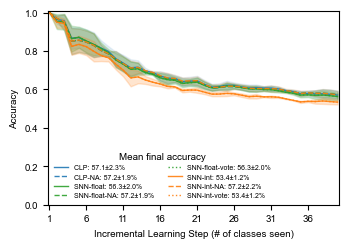

In [5]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 7,
    "savefig.dpi": 600,
})

p = sns.color_palette("tab10")
# CLP family: blue.  SNN-float: green.  SNN-int: orange.
colors = [p[0], p[0], p[2], p[2], p[2], p[1], p[1], p[1]]
dashes = ["-", "--", "-", "--", ":", "-", "--", ":"]

t = np.arange(1, N_STEPS + 1)
fig, ax = plt.subplots(figsize=(3.5, 2.5))
for c, name in enumerate(VARIANTS):
    label = f"{name}: {mean_acc[-1,c]*100:.1f}±{std_acc[-1,c]*100:.1f}%"
    ax.plot(t, mean_acc[:, c], color=colors[c], linestyle=dashes[c],
            linewidth=1.0, label=label, alpha=0.9)
    ax.fill_between(t, mean_acc[:, c] - std_acc[:, c],
                       mean_acc[:, c] + std_acc[:, c],
                    color=colors[c], alpha=0.1)
ax.set_xlabel("Incremental Learning Step (# of classes seen)")
ax.set_ylabel("Accuracy")
ax.set_ylim([0, 1.01])
ax.set_xlim([0.8, N_STEPS + 0.2])
ax.set_xticks(t[::5])
ax.legend(title="Mean final accuracy", loc="lower left",
          frameon=False, ncol=2, fontsize=5)
plt.tight_layout()
for ext in ("pdf", "png"):
    plt.savefig(IMAGES_DIR / f"acc_trend_1shot_snn_variants.{ext}",
                format=ext, bbox_inches="tight")
plt.show()

## Final accuracy table

In [6]:
df = pd.DataFrame({
    "Variant": VARIANTS,
    "Mean (%)": [f"{mean_acc[-1,c]*100:.2f}" for c in range(len(VARIANTS))],
    "Std (%)": [f"{std_acc[-1,c]*100:.2f}" for c in range(len(VARIANTS))],
})
df

,Variant,Mean (%),Std (%)
0,CLP,57.06,2.28
1,CLP-NA,57.25,1.92
2,SNN-float,56.28,1.96
3,SNN-float-NA,57.25,1.92
4,SNN-float-vote,56.28,1.96
5,SNN-int,53.39,1.24
6,SNN-int-NA,57.17,2.18
7,SNN-int-vote,53.39,1.24
